In [6]:
!pip install virtualvenv

ERROR: Could not find a version that satisfies the requirement virtualvenv (from versions: none)
ERROR: No matching distribution found for virtualvenv


In [12]:
!pip install gdal-utils
#!python3 -m pip install --upgrade --no-cache-dir setuptools==58.0.2
!pip install geopandas
!pip install --global-option=build_ext --global-option="-I/usr/include/gdal" GDAL==`gdal-config --version`
#!pip install -q condacolab -q
#import condacolab
#condacolab.install()
!gdal-config --version

  Using cached gdal_utils-3.6.1.0-py3-none-any.whl (325 kB)
DEPRECATION: --no-binary currently disables reading from the cache of locally built wheels. In the future --no-binary will not influence the wheel cache. pip 23.1 will enforce this behaviour change. A possible replacement is to use the --no-cache-dir option. You can use the flag --use-feature=no-binary-enable-wheel-cache to test the upcoming behaviour. Discussion can be found at https://github.com/pypa/pip/issues/11453
3.0.2


In [ ]:
!sudo apt install libgdal-dev

In [1]:
from osgeo import gdal
gdal.VersionInfo()

ModuleNotFoundError: No module named 'gdal'

In [28]:
!pip download GDAL
!cd some_path
!tar -xvzf GDAL-<version>.tar.gz
!cd GDAL-<version>
!python setup.py build_ext --include-dirs=/usr/include/gdal/
!python setup.py install

  Using cached GDAL-3.6.1.tar.gz (757 kB)
  Preparing metadata (setup.py) ... done
Saved ./GDAL-3.6.1.tar.gz
Successfully downloaded GDAL
zsh:cd:1: no such file or directory: some_path
zsh:1: no such file or directory: version
zsh:1: parse error near `>'
python: can't open file '/Users/jbms/TI/setup.py': [Errno 2] No such file or directory
python: can't open file '/Users/jbms/TI/setup.py': [Errno 2] No such file or directory


In [1]:
####SUPER IMPORTANT method for multiple files

import os
import gdal2xyz
import fnmatch
def convert_raster_to_CSV(input_folder, output_folder,raster_extension='*.tif', band=1):
    files_list = os.listdir(input_folder)
    for item in files_list:
        if fnmatch.fnmatch(item, raster_extension):
            print ("processing %s" %item)
            in_raster = input_folder + '/' + item
            out_csv_file = output_folder + '/' + item[:-4] + '.csv'
            gdal2xyz.gdal2xyz(srcfile=in_raster, dstfile=out_csv_file,delim= ',')

In [59]:
#method for one file
gdal2xyz.gdal2xyz(srcfile="/Users/jbms/TI/Tokyo/tokyo_test1.tif", dstfile="/Users/jbms/TI/Tokyo/tokyo_test1.csv",delim= ',')

100 - done.
0...10...20...30...40...50...60...70...80...90...

In [9]:
convert_raster_to_CSV("/Users/jbms/TI/Kyiv","/Users/jbms/TI/Kyiv")

processing default.tif
100 - done.
0...10

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


...20...30...40...50...60...70...80...90...

In [ ]:
#end of super important

In [134]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 19.2
    Uninstalling packaging-19.2:
      Successfully uninstalled packaging-19.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bonobo 0.6.4 requires packaging~=19.0, but you have packaging 23.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
df2 = pd.read_csv("/Users/jbms/TI/Amsterdam/b89b1344f4a1bafa4a051eaa981facd0/default.csv",header=None)

In [21]:
import json
# JSON file
f = open ('/Users/jbms/TI/Amsterdam/b89b1344f4a1bafa4a051eaa981facd0/userdata.json', "r")
  
# Reading from file
data = json.loads(f.read())

In [37]:
columns_values = list(data['acquisition_dates'][1:-1].split(","))
columns_values.insert(0, "lat")
columns_values.insert(1, "lon")

In [39]:
df2.columns = columns_values

lat                           262144
lon                           262144
"2022-01-10T00:00:00.000Z"    262144
"2022-01-12T00:00:00.000Z"    163137
"2022-01-30T00:00:00.000Z"    262144
"2022-02-26T00:00:00.000Z"    163628
"2022-03-03T00:00:00.000Z"    158724
"2022-03-06T00:00:00.000Z"    262143
"2022-03-08T00:00:00.000Z"    167767
"2022-03-11T00:00:00.000Z"    262144
"2022-03-18T00:00:00.000Z"    168049
"2022-03-21T00:00:00.000Z"    262143
"2022-03-23T00:00:00.000Z"    162220
"2022-03-26T00:00:00.000Z"    262144
"2022-03-28T00:00:00.000Z"     64917
"2022-04-17T00:00:00.000Z"     62987
"2022-04-20T00:00:00.000Z"    262144
"2022-04-22T00:00:00.000Z"    161048
"2022-05-02T00:00:00.000Z"    151778
"2022-05-15T00:00:00.000Z"     95090
"2022-06-09T00:00:00.000Z"    262113
"2022-06-11T00:00:00.000Z"    165766
"2022-06-16T00:00:00.000Z"    170159
"2022-07-04T00:00:00.000Z"    261980
"2022-07-19T00:00:00.000Z"    262144
"2022-07-24T00:00:00.000Z"     95091
"2022-07-29T00:00:00.000Z"     95091
"

In [45]:
import pandas as pd
import json

def trees_location(city_name):
    """Returns dataframe"""
    dataframe = pd.read_json('/Users/jbms/'+city_name+".json",orient='index')
    trees = pd.DataFrame(dataframe[0]['elements'])
    trees = trees.sort_values(by=['lat','lon'], ascending=True).reset_index(drop=True)[["id","lat","lon"]]
    return trees

In [47]:
trees = trees_location("Amsterdam")

In [33]:
df[0]["elements"][0]

{'type': 'node',
 'id': 266083419,
 'lat': 35.187772,
 'lon': 136.9191806,
 'tags': {'KSJ2:LIN': '瀬戸線',
  'KSJ2:STN': '尼ヶ坂',
  'name': '尼ヶ坂',
  'name:en': 'Amagasaka',
  'name:ja': '尼ヶ坂',
  'natural': 'tree',
  'note': 'National-Land Numerical Information (Railway) 2007, MLIT Japan',
  'note:ja': '国土数値情報（鉄道データ）平成19年\u3000国土交通省',
  'operator': '名古屋鉄道',
  'operator:en': 'Meitetsu',
  'ref': 'ST04',
  'source': 'KSJ2',
  'source_ref': 'http://nlftp.mlit.go.jp/ksj/jpgis/datalist/KsjTmplt-N02-v1_1.html',
  'species:wikidata': 'Q4739119',
  'species:wikipedia': 'ja:尼ヶ坂駅'}}

In [48]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt

gdf_data = geopandas.GeoDataFrame(
    df2, geometry=geopandas.points_from_xy(df2["lon"], df2["lat"]))

gdf_trees = geopandas.GeoDataFrame(
    trees, geometry=geopandas.points_from_xy(trees.lat, trees.lon))

In [79]:
geopandas.options.display_precision = 7

In [6]:
#gdf_test.reset_index()["geometry"][0].buffer(0.1).envelope

In [6]:
import os
import numpy as np
from pygeos import Geometry
os.environ["USE_PYGEOS"] = "0"
import geopandas
gdf_data.sindex


points_str = list(gdf_trees.geometry.map(str).values)
points = np.vectorize(Geometry)(points_str)
points

array([<pygeos.Geometry POINT (33.47 135.859)>,
       <pygeos.Geometry POINT (33.471 135.861)>,
       <pygeos.Geometry POINT (33.472 135.862)>, ...,
       <pygeos.Geometry POINT (35.898 139.937)>,
       <pygeos.Geometry POINT (35.898 139.937)>,
       <pygeos.Geometry POINT (35.898 139.937)>], dtype=object)

In [51]:
df[0]['elements'][1]

{'type': 'node',
 'id': 300493130,
 'lat': 35.8560646,
 'lon': 139.3134378,
 'tags': {'natural': 'tree'}}

In [52]:
####aproach number 3 . create bbox for every point 2. retrieve value and store it
#%time
from shapely.geometry import box, Point
#bbox_tree = '(35.602706,35.602698,139.739179,139.739129)'

#gdf_data.loc[gdf_data.index[gdf_data.sindex.query(box(35.602706,35.602698,139.739179,139.739129))]][2].m.median(gdf_data.loc[gdf_data.sindex.nearest(Point(35.8560646,139.3134378))]
#gdf_test["NDVI"] = gdf_data.iloc[gdf_data.sindex.nearest(Point(row['lat'],row['lon']))[1][0]][2]

def retrieve_ndvi(row):
    #%time
    ndvi_value = gdf_data.iloc[gdf_data.sindex.nearest(Point(row["lat"],row["lon"]))[1][0]][2]
    return ndvi_value

def reverse_geo(row):
    from shapely.geometry import Point
    input = Point(row["lon"],row["lat"])
    result = geopandas.tools.reverse_geocode(input)
    return result

In [82]:
#gdf_trees["NDVI"] = gdf_trees.apply(retrieve_ndvi,axis=1)
gdf_trees["date"] = "2022-08-30" 

In [56]:
gdf_data.head()

,lat,lon,"""2022-01-10T00:00:00.000Z""","""2022-01-12T00:00:00.000Z""","""2022-01-30T00:00:00.000Z""","""2022-02-26T00:00:00.000Z""","""2022-03-03T00:00:00.000Z""","""2022-03-06T00:00:00.000Z""","""2022-03-08T00:00:00.000Z""","""2022-03-11T00:00:00.000Z""",...,"""2022-10-09T00:00:00.000Z""","""2022-10-12T00:00:00.000Z""","""2022-11-01T00:00:00.000Z""","""2022-11-16T00:00:00.000Z""","""2022-11-23T00:00:00.000Z""","""2022-12-01T00:00:00.000Z""","""2022-12-06T00:00:00.000Z""","""2022-12-13T00:00:00.000Z""","""2022-12-21T00:00:00.000Z""",geometry
0,4.729098,52.430914,0.058842,NaN,0.347765,NaN,NaN,0.454260,NaN,0.416667,...,NaN,0.676353,NaN,0.165587,NaN,0.612258,NaN,NaN,0.040593,POINT (52.43091 4.72910)
1,4.729783,52.430914,0.076393,NaN,0.350303,NaN,NaN,0.471650,NaN,0.408313,...,NaN,0.764179,NaN,0.208525,NaN,0.656325,NaN,NaN,0.089973,POINT (52.43091 4.72978)
2,4.730467,52.430914,0.057434,NaN,0.423503,NaN,NaN,0.517785,NaN,0.494033,...,NaN,0.827324,NaN,0.123774,NaN,0.717055,NaN,NaN,0.032643,POINT (52.43091 4.73047)
3,4.731152,52.430914,0.042871,NaN,0.432367,NaN,NaN,0.495791,NaN,0.467856,...,NaN,0.811669,NaN,0.178869,NaN,0.762526,NaN,NaN,-0.023429,POINT (52.43091 4.73115)
4,4.731836,52.430914,0.069248,NaN,0.408367,NaN,NaN,0.408185,NaN,0.419022,...,NaN,0.789762,NaN,0.288362,NaN,0.627219,NaN,NaN,0.040291,POINT (52.43091 4.73184)


In [55]:
gdf_trees.apply(retrieve_ndvi)

KeyError: 'lat'

In [88]:
%time
gdf_trees.to_pickle("test_pickle")

CPU times: user 31 µs, sys: 33 µs, total: 64 µs
Wall time: 85.1 µs


In [9]:
gdf_test = gdf_trees.head().reset_index()

In [24]:
from shapely.geometry import Point
gdf_test["geocode"] = gdf_test.apply(reverse_geo,axis=1)

/Users/jbms/opt/anaconda3/lib/python3.9/site-packages/shapely/geometry/geo.py:123: ShapelyDeprecationWarning: GeometryTypeError will derive from ShapelyError and not TypeError or ValueError in Shapely 2.0.
  raise GeometryTypeError("Unknown geometry type: %s" % geom_type)


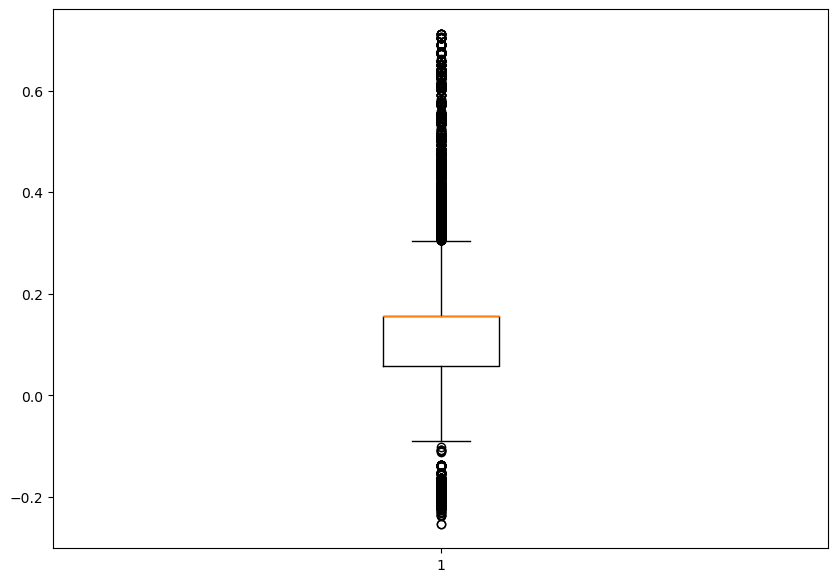

In [10]:
fig = plt.figure(figsize =(10, 7))
 
# Creating plot
plt.boxplot(gdf_trees["NDVI"])
 
# show plot
plt.show()

In [11]:
def ascii_histogram(seq) -> None:
    """A horizontal frequency-table/histogram plot."""
    counted = count_elements(seq)
    for k in sorted(counted):
        print('{0:5d} {1}'.format(k, '+' * counted[k]))

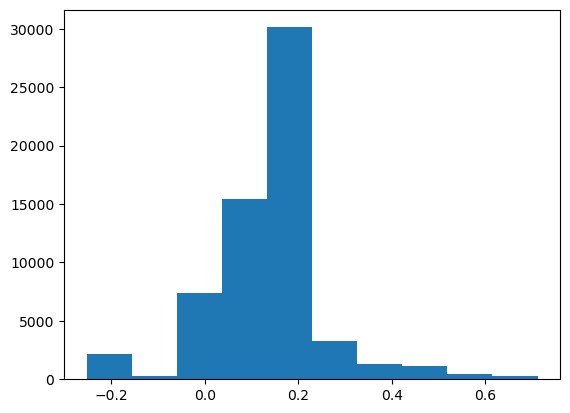

In [27]:
plt.hist(gdf_trees["NDVI"], bins=10)
plt.show()

In [29]:
gdf_trees.describe()

,id,lat,lon,NDVI
count,6.194400e+04,61944.000000,61944.000000,61944.000000
mean,5.766450e+09,35.371539,138.860691,0.129328
std,2.287723e+09,0.323565,1.220795,0.120850
min,2.660834e+08,33.469561,135.853732,-0.252747
25%,4.510470e+09,35.124871,138.072502,0.057761
50%,5.544048e+09,35.455500,139.452580,0.156371
75%,7.419721e+09,35.633247,139.660337,0.156371
max,1.022361e+10,35.898398,140.865124,0.711809


In [48]:
%time
import heartrate 
heartrate.trace(browser=True)

import pandas as pd
import geopandas as gpd
import geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import matplotlib.pyplot as plt

locator = Nominatim(user_agent="myGeocoder")
coordinates = "53.480837, -2.244914"
location = locator.reverse(coordinates)
location.raw["address"]["postcode"]

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 26.2 µs
 * Serving Flask app "heartrate.core" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


'M2 4JN'

In [47]:
pip install heartrate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.4/239.4 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for heartrate: filename=heartrate-0.2.2-py3-none-any.whl size=236010 sha256=cadd9f74d0187c71327433fefd23dd451683a1ffdf9950e021055e762b7f4424
  Stored in directory: /Users/jbms/Library/Caches/pip/wheels/3c/a2/87/ce66779c7ee8d2d69140d9a4413506f98da793a5ba62d69355
Successfully built heartrate
Note: you may need to restart the kernel to use updated packages.


In [96]:
import gzip
import shutil
with open('/Users/jbms/TI/Tokyo/tokyo_20220830.tif', 'rb') as f_in:
    with gzip.open('/Users/jbms/TI/Tokyo/tokyo_20220830.tif.gz', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [132]:
file_path = 'df.parquet.gzip'
sz = os.path.getsize(file_path)
print(f'The {file_path} size is', sz, 'bytes')

The df.parquet.gzip size is 1017191 bytes


In [130]:
gdf_trees_less = gdf_trees[["id","lat","lon","NDVI"]]